# Employee Performance Analysis System

## Overview

This project analyzes employee performance data to identify high-performing employees, evaluate departmental performance, and understand factors affecting employee productivity. The analysis includes data cleaning, exploratory data analysis, statistical summaries, and visualizations to support HR decision-making.

## Objective

The objective of this project is to analyze employee performance data to:

- Identify top-performing employees
- Understand performance trends across departments
- Analyze the relationship between salary and performance
- Study the impact of employee experience on performance
- Provide actionable recommendations to HR

# 1. Import Libraries

The following libraries are used for data manipulation,
analysis, and visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


# 2. Data Loading

The employee dataset is loaded into a Pandas DataFrame
for further analysis.

In [6]:
df = pd.read_csv("Employee_Data.csv")

# 3. Data Exploration

This section examines the structure of the dataset,
including dimensions, data types, missing values,
and summary statistics.

In [7]:
df.head(10)

,ID,Name,Age,Gender,Department,Salary,Joining Date,Performance Score,Experience,Status,Location,Session
0,1,Cory Escobar,48,Female,HR,5641,2015-05-03,2.0,16,Active,New York,Night
1,2,Timothy Sanchez,25,Other,Sales,4249,2020-11-09,2.0,11,Inactive,Los Angeles,Evening
2,3,Chad Nichols,57,Other,Sales,3058,2019-02-12,NaN,1,Inactive,New York,Morning
3,4,Christine Williams,58,Female,IT,5895,2017-09-08,2.0,13,Inactive,Los Angeles,Evening
4,5,Amber Harris,35,Other,IT,4317,2020-02-15,5.0,16,Inactive,New York,Evening
5,6,Ashley Howe,29,Female,HR,2591,2016-06-24,1.0,6,Active,Chicago,Evening
6,7,David Olson,39,Female,Sales,6826,2023-05-11,NaN,4,Active,New York,Night
7,8,Amanda Baker,52,Other,HR,6285,2015-04-01,NaN,8,Inactive,Chicago,Evening
8,9,Jeremy Wright,63,Female,Sales,9862,2024-02-07,NaN,3,Inactive,New York,Night
9,10,Brian Faulkner,30,Male,IT,8202,2018-05-26,1.0,9,Active,Los Angeles,Morning


In [8]:
df.shape

(1000, 12)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 1000 non-null   int64  
 1   Name               1000 non-null   object 
 2   Age                1000 non-null   int64  
 3   Gender             1000 non-null   object 
 4   Department         1000 non-null   object 
 5   Salary             1000 non-null   int64  
 6   Joining Date       1000 non-null   object 
 7   Performance Score  502 non-null    float64
 8   Experience         1000 non-null   int64  
 9   Status             1000 non-null   object 
 10  Location           1000 non-null   object 
 11  Session            1000 non-null   object 
dtypes: float64(1), int64(4), object(7)
memory usage: 93.9+ KB


In [13]:
df.isnull().sum()

ID                     0
Name                   0
Age                    0
Gender                 0
Department             0
Salary                 0
Joining Date           0
Performance Score    498
Experience             0
Status                 0
Location               0
Session                0
dtype: int64

In [14]:
df.describe()

,ID,Age,Salary,Performance Score,Experience
count,1000.000000,1000.000000,1000.000000,502.000000,1000.000000
mean,500.500000,40.782000,5917.374000,2.910359,10.120000
std,288.819436,14.124871,2299.418003,1.424736,5.713689
min,1.000000,18.000000,2015.000000,1.000000,1.000000
25%,250.750000,28.000000,3829.750000,2.000000,5.000000
50%,500.500000,40.000000,5889.000000,3.000000,10.000000
75%,750.250000,52.000000,7903.250000,4.000000,15.000000
max,1000.000000,65.000000,9993.000000,5.000000,20.000000


## Observations

- The dataset contains 1000 employee records and 12 variables.
- Employee information includes demographic, salary, department, and performance-related attributes.
- Performance Score contained 498 missing values.
- No missing values were found in the remaining columns.
- Joining Date was stored as an object data type and required conversion to datetime format.

# 4. Data Cleaning

Data cleaning was performed to improve data quality.

Steps:
1. Missing values handled
2. Duplicate records removed
3. Data types verified

In [15]:
df["Performance Score"].describe()

count    502.000000
mean       2.910359
std        1.424736
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: Performance Score, dtype: float64

In [16]:
df["Performance Score"].value_counts().head(20)

Performance Score
2.0    125
1.0    103
5.0     99
4.0     88
3.0     87
Name: count, dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [20]:
df["Performance Score"] = df["Performance Score"].fillna(
    df["Performance Score"].median()
)

In [22]:
df.isnull().sum()

ID                   0
Name                 0
Age                  0
Gender               0
Department           0
Salary               0
Joining Date         0
Performance Score    0
Experience           0
Status               0
Location             0
Session              0
dtype: int64

In [21]:
df["Performance Score"].value_counts()

Performance Score
3.0    585
2.0    125
1.0    103
5.0     99
4.0     88
Name: count, dtype: int64

In [23]:
df["Joining Date"] = pd.to_datetime(df["Joining Date"])

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ID                 1000 non-null   int64         
 1   Name               1000 non-null   object        
 2   Age                1000 non-null   int64         
 3   Gender             1000 non-null   object        
 4   Department         1000 non-null   object        
 5   Salary             1000 non-null   int64         
 6   Joining Date       1000 non-null   datetime64[ns]
 7   Performance Score  1000 non-null   float64       
 8   Experience         1000 non-null   int64         
 9   Status             1000 non-null   object        
 10  Location           1000 non-null   object        
 11  Session            1000 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(6)
memory usage: 93.9+ KB


In [25]:
df.columns

Index(['ID', 'Name', 'Age', 'Gender', 'Department', 'Salary', 'Joining Date',
       'Performance Score', 'Experience', 'Status', 'Location', 'Session'],
      dtype='object')

## Data Cleaning Decisions

- Performance Score contained 498 missing values.
- Missing values were replaced using the median value (3).
- No duplicate records were found in the dataset.
- Joining Date was converted to datetime format.

## Performance Analysis

### 1. Average Performance by Department

Business Question: Which department performs best?


In [26]:
dept_performance = df.groupby("Department")["Performance Score"].mean()

dept_performance.sort_values(ascending=False)

Department
IT       2.988201
Sales    2.949704
HR       2.925697
Name: Performance Score, dtype: float64

**Interpretation:**

IT recorded the highest average performance score (2.99), followed by Sales (2.95) and HR (2.93). The difference between departments is minimal, indicating relatively consistent performance levels across the organization.

### 2. Top 10 Performers

Business Question: Who should HR consider for promotion?

In [27]:
top10 = df.nlargest(10, "Performance Score")

top10[[
    "Name",
    "Department",
    "Performance Score",
    "Salary"
]]

,Name,Department,Performance Score,Salary
4,Amber Harris,IT,5.0,4317
18,Nancy Stephens,HR,5.0,9061
25,Tara Blackwell,HR,5.0,6120
26,Austin Long,IT,5.0,4899
38,Jordan Scott,Sales,5.0,8678
53,Taylor Griffin,Sales,5.0,5721
59,Melinda Tyler,Sales,5.0,5937
103,Jose Henson,HR,5.0,6458
104,Isaiah Sanders DDS,HR,5.0,2752
107,Sandra Allen,IT,5.0,2578


**Interpretation:**

Top-performing employees achieved a performance score of 5 and were distributed across HR, Sales, and IT departments.

### 3. Performance Distribution
Business Question: How are employees distributed across performance levels?

In [28]:
df["Performance Score"].describe()

count    1000.000000
mean        2.955000
std         1.009948
min         1.000000
25%         3.000000
50%         3.000000
75%         3.000000
max         5.000000
Name: Performance Score, dtype: float64

**Interpretation:**

The average employee performance score is approximately 2.96 out of 5. Most employees are concentrated around a performance score of 3.

### 4. Salary vs Performance Analysis
Business Question: Are high performers paid more?

In [29]:
df[[
    "Salary",
    "Performance Score"
]].corr()

,Salary,Performance Score
Salary,1.000000,0.001703
Performance Score,0.001703,1.000000


**Interpretation:**

The correlation between salary and performance is approximately 0.0017, indicating no meaningful relationship between employee salary and performance.

### 5. Experience vs Performance Analysis
Business Question: Does experience improve performance?

In [30]:
df[[
    "Experience",
    "Performance Score"
]].corr()

,Experience,Performance Score
Experience,1.000000,-0.007043
Performance Score,-0.007043,1.000000


**Interpretation:**

The correlation between experience and performance is approximately -0.007, indicating no significant relationship between employee experience and performance.

In [35]:
sns.set_style("whitegrid")

## Visualizations

### Visualization 1: Performance Distribution Histogram

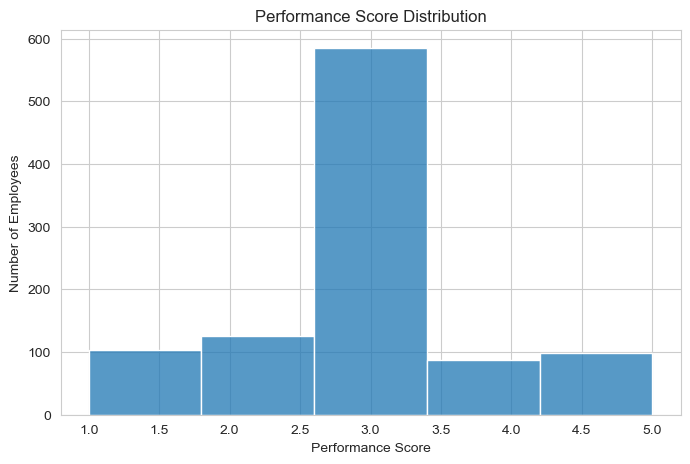

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Performance Score"],
    bins=5
)

plt.title("Performance Score Distribution")
plt.xlabel("Performance Score")
plt.ylabel("Number of Employees")

plt.savefig(
    "performance_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Interpretation:**

Most employees have a performance score of 3, indicating average overall performance levels.

### Visualization 2: Department-wise Performance (Bar Chart)

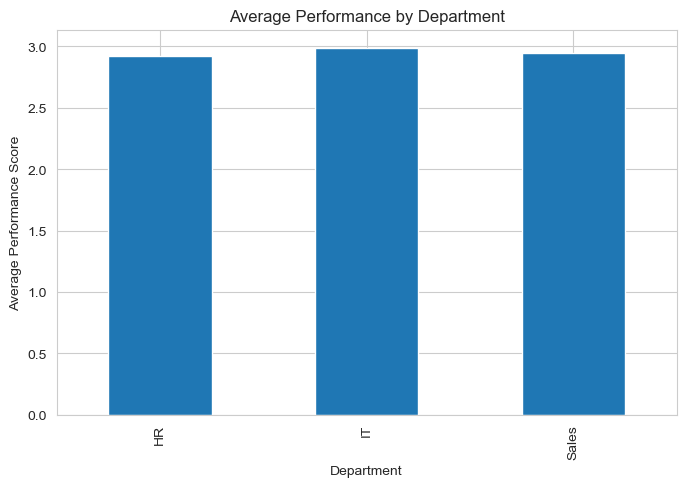

In [42]:
dept_performance = df.groupby(
    "Department"
)["Performance Score"].mean()

plt.figure(figsize=(8,5))

dept_performance.plot(
    kind="bar"
)

plt.title("Average Performance by Department")
plt.xlabel("Department")
plt.ylabel("Average Performance Score")

plt.savefig(
    "department_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Interpretation:**

IT achieved the highest average performance score, although differences among departments remain small.

### Visualization 3: Salary vs Performance Scatter Plot

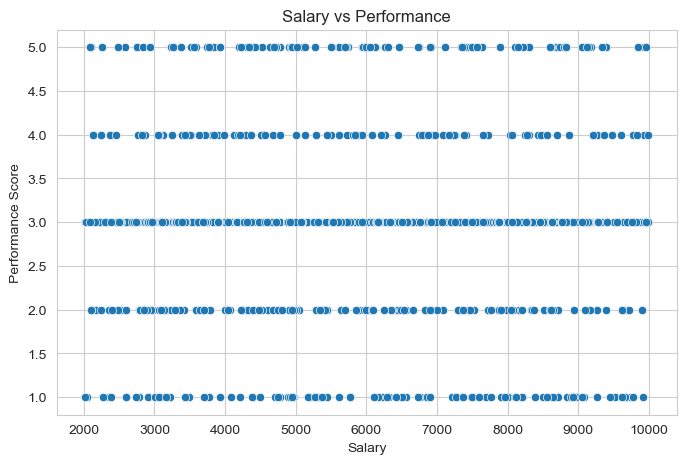

In [43]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Salary",
    y="Performance Score"
)

plt.title("Salary vs Performance")
plt.xlabel("Salary")
plt.ylabel("Performance Score")

plt.savefig(
    "salary_vs_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Interpretation:**

The scatter plot shows no visible trend between salary and performance, supporting the correlation analysis.

### Visualization 4: Performance by Experience (Line Chart)

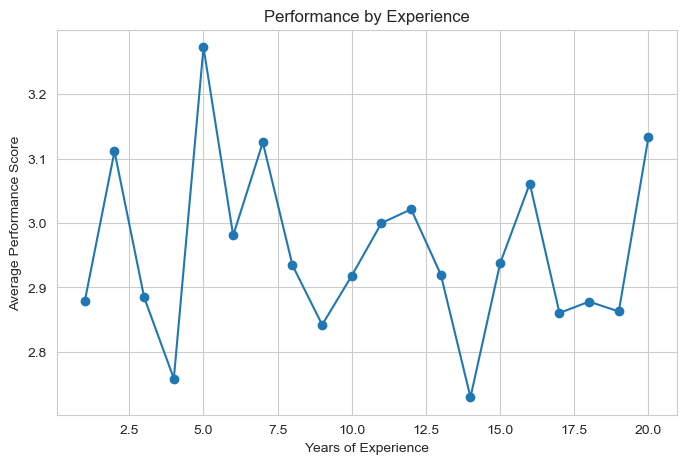

In [44]:
exp_perf = df.groupby(
    "Experience"
)["Performance Score"].mean()

plt.figure(figsize=(8,5))

exp_perf.plot(
    kind="line",
    marker="o"
)

plt.title("Performance by Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Average Performance Score")

plt.savefig(
    "performance_vs_experience.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Interpretation:**

Average performance remains relatively stable across experience levels. No strong relationship between experience and performance was observed.

## Executive Summary

### Overview
This project analyzed employee performance data to identify performance trends, evaluate departmental performance, and examine the relationship between employee performance, salary, and experience.

### Key Findings
- The dataset contained 1000 employee records.
- IT recorded the highest average performance score (2.99), followed by Sales (2.95) and HR (2.93).
- The overall average employee performance score was 2.96 out of 5.
- Salary and performance showed almost no correlation (0.0017).
- Experience and performance also showed no meaningful correlation (-0.007).
- Top-performing employees achieved a performance score of 5 and were distributed across multiple departments.

### Recommendations

- Recognize and reward high-performing employees.
- Monitor departmental performance regularly.
- Evaluate employees based on performance metrics rather than salary or experience alone.
- Improve performance data collection processes to reduce missing values.

### Conclusion

The analysis revealed relatively consistent performance levels across departments. No significant relationship was found between employee performance, salary, or experience. The findings highlight the importance of performance-based evaluation and continuous monitoring to support effective HR decision-making.